In [1]:
%matplotlib inline
%load_ext autoreload
%autoreload 2
import matplotlib.pyplot as plt
import sigpy as sp
import pandas as pd
import sigpy.plot as pl
import numpy as np
import os
ksp = np.load(r"/Users/ayman/Library/CloudStorage/OneDrive-King'sCollegeLondon/Project/Sigpytutorial/projection_ksp.npy")
coord = np.load(r"/Users/ayman/Library/CloudStorage/OneDrive-King'sCollegeLondon/Project/Sigpytutorial/projection_coord.npy")

import aymansigmri as asm

In [2]:
zte_radial_kspace, zte_radial_coords = asm.generate_zte_data_OLD(ksp=ksp, coord=coord, n_missing=0, undersampling_factor=1)

kspace_cart_coils = asm.gridding_operator(kspace_data=zte_radial_kspace, coord=zte_radial_coords)
#radial_interp_coils = asm.gridding_operator_H(cartesian_data=kspace_cart_coils, coord=zte_radial_coords)

## Problem - NUFFT Degridding

- Current Loss of Information

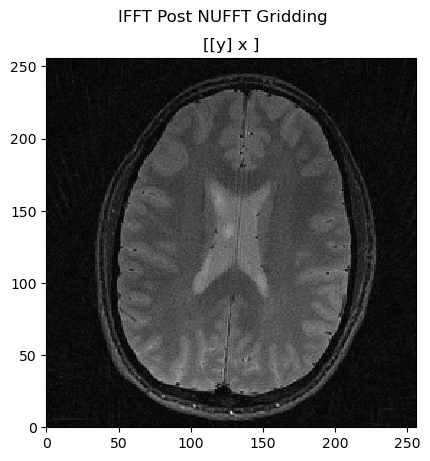

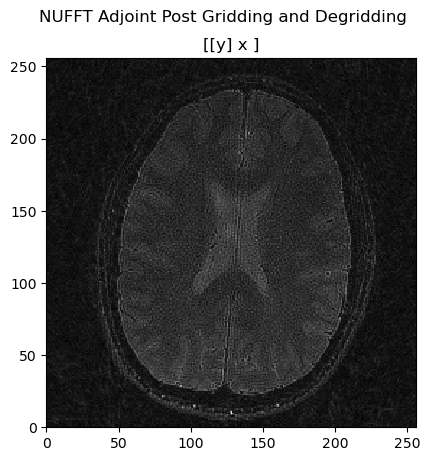

In [ ]:
# Plot the image after gridding and then again after degridding
zte_cart_kspace_imgtrip = asm.nufft_gridding(kspace=zte_radial_kspace, coords=zte_radial_coords)

#Post grid
im_cart_grid = sp.ifft(zte_cart_kspace_imgtrip)
im_rss_cart = np.sum(np.abs(im_cart_grid)**2, axis=0)**0.5
pl.ImagePlot(im_rss_cart,title='IFFT Post NUFFT Gridding')


#Post degrid
radial_post_imtrip = sp.nufft(im_cart_grid, zte_radial_coords, oversamp=1, width=10)
dcf = np.sqrt(zte_radial_coords[..., 0]**2 + zte_radial_coords[..., 1]**2)
zte_img_grid = sp.nufft_adjoint(radial_post_imtrip * dcf, zte_radial_coords)
zte_img_rss = np.sum(np.abs(zte_img_grid)**2, axis=0)**0.5
pl.ImagePlot(zte_img_rss, title='NUFFT Adjoint Post Gridding and Degridding')

## Investigating image difference

In [92]:
### Original Image
dcf = np.sqrt(zte_radial_coords[..., 0]**2 + zte_radial_coords[..., 1]**2)
zte_orig_grid = sp.nufft_adjoint(zte_radial_kspace * dcf, zte_radial_coords)
zte_orig_image = np.sum(np.abs(zte_orig_grid)**2, axis=0)**0.5


### Post gridding with nufft
zte_cart_kspace_imgtrip = asm.nufft_gridding(kspace=zte_radial_kspace, coords=zte_radial_coords)
im_cart_grid = sp.ifft(zte_cart_kspace_imgtrip)
im_rss_cart = np.sum(np.abs(im_cart_grid)**2, axis=0)**0.5


### Post image - nufft on the cartesian image grid
radial_post_imtrip = sp.nufft(im_cart_grid, zte_radial_coords, oversamp=1, width=10)
dcf = np.sqrt(zte_radial_coords[..., 0]**2 + zte_radial_coords[..., 1]**2)

zte_img_grid = sp.nufft_adjoint(radial_post_imtrip * dcf, zte_radial_coords)
zte_img_rss = np.sum(np.abs(zte_img_grid)**2, axis=0)**0.5


#Div to find scaling problem
div = zte_img_rss / im_rss_cart

In [ ]:
print(np.percentile(np.abs(zte_img_rss), 90)) 
print(np.percentile(np.abs(zte_img_rss), 95)) 
print(np.percentile(np.abs(zte_img_rss), 99))   
print(np.abs(zte_img_rss).max())                
print(np.percentile(np.abs(im_rss_cart), 99))
print(np.abs(im_rss_cart).max())

0.41684867465890907
0.46270716712722865
0.558242039665469
1.5790846543992287
0.007234727665061423
0.014283996927093479


### Plot with colourbars
- reveals scaling issue in the operations

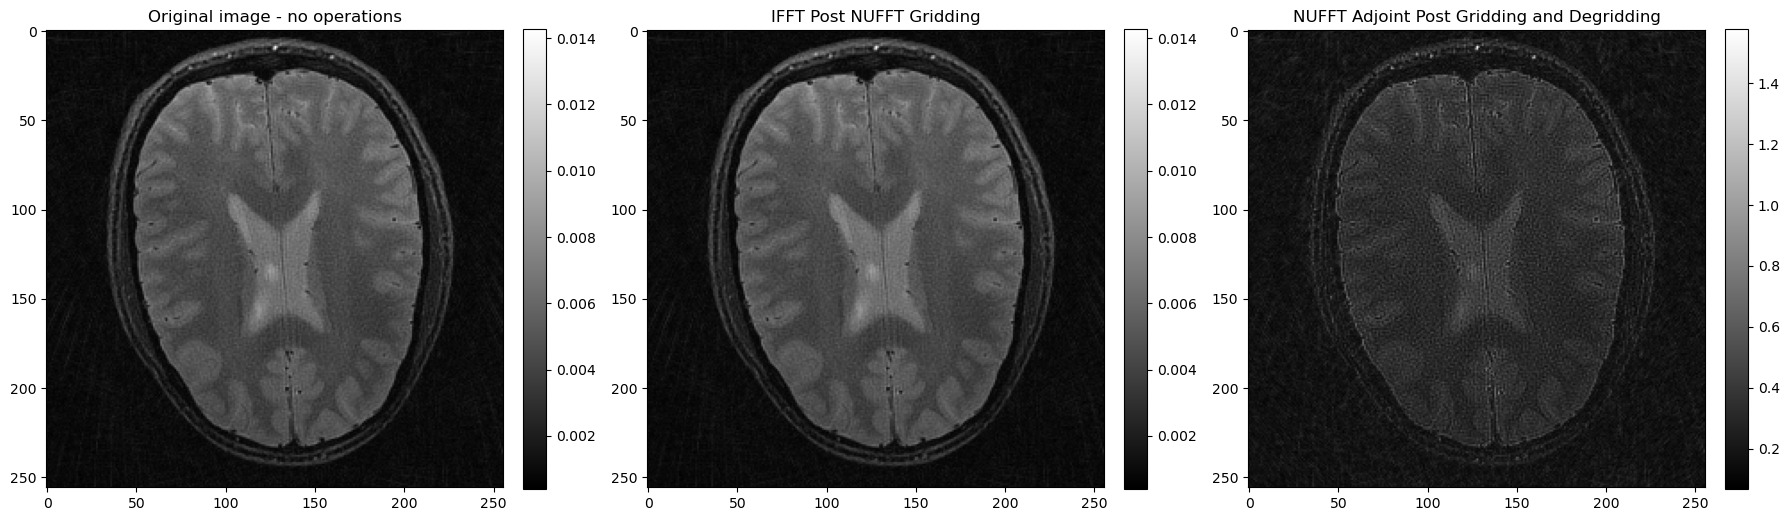

In [99]:
fig, ax = plt.subplots(1, 3, figsize=(18, 8))

im0 = ax[0].imshow(zte_orig_image, cmap='gray')
ax[0].set_title('Original image - no operations')
plt.colorbar(im0, ax=ax[0], fraction=0.046, pad=0.04)

im1 = ax[1].imshow(im_rss_cart, cmap='gray')
ax[1].set_title('IFFT Post NUFFT Gridding')
plt.colorbar(im1, ax=ax[1], fraction=0.046, pad=0.04)

im2 = ax[2].imshow(zte_img_rss, cmap='gray')
ax[2].set_title('NUFFT Adjoint Post Gridding and Degridding')
plt.colorbar(im2, ax=ax[2], fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()

### Plot kspace vals

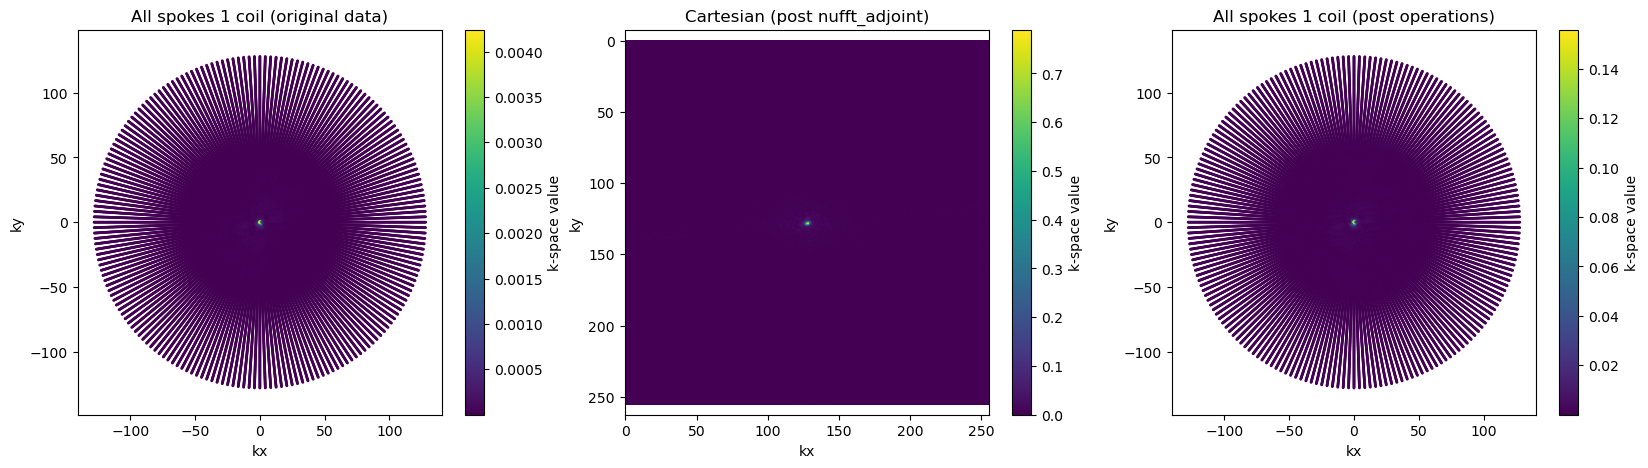

In [106]:
fig, ax = plt.subplots(nrows=1, ncols=3, figsize=(20,5))

all_coords = zte_radial_coords.reshape(-1,2)
all_kspace = zte_radial_kspace[0].reshape(-1)

all_kspace_postim = radial_post_imtrip[0].reshape(-1)


im0 = ax[0].scatter(all_coords[:, 0], all_coords[:, 1], c=np.abs(all_kspace), s=1)
ax[0].set_title('All spokes 1 coil (original data)')
ax[0].set_xlabel('kx')
ax[0].set_ylabel('ky')
ax[0].axis('equal')
fig.colorbar(im0, ax=ax[0], label='k-space value')

im1 = ax[1].imshow(np.abs(kspace_cart_coils[0]))
ax[1].set_title('Cartesian (post nufft_adjoint)')
ax[1].set_xlabel('kx')
ax[1].set_ylabel('ky')
ax[1].axis('equal')
fig.colorbar(im1, ax=ax[1], label='k-space value')

im1 = ax[2].scatter(all_coords[:, 0], all_coords[:, 1], c=np.abs(all_kspace_postim), s=1)
ax[2].set_title('All spokes 1 coil (post operations)')
ax[2].set_xlabel('kx')
ax[2].set_ylabel('ky')
ax[2].axis('equal')
fig.colorbar(im1, ax=ax[2], label='k-space value')




plt.show()

In [24]:
test_round_trip = sp.nufft_adjoint(sp.nufft(im_cart_grid, zte_radial_coords), zte_radial_coords)
scale_factor =  np.abs(test_round_trip).max() / np.abs(im_cart_grid).max()
print(f"Scale factor: {scale_factor:.4f}") 

Scale factor: 31.7312
